# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Evelyn Chen and Natalie Ho 

**ID**: ec877, nh424

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE_4750/hw3-natalie-evelyn`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.35 km


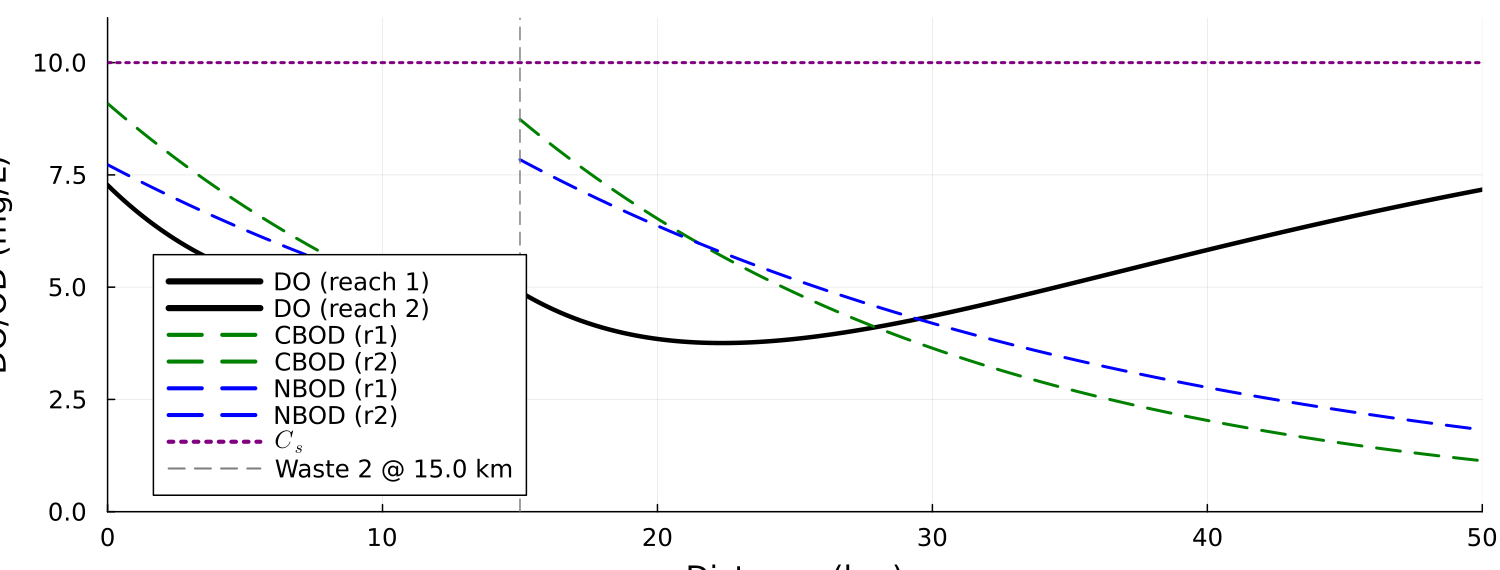

In [3]:
using Plots
using LaTeXStrings

function do_simulate(x, C0, B0, N0, ka, kc, kn, Cs, U)
    B = B0 * exp(-kc * x / U)
    N = N0 * exp(-kn * x / U)

    α1 = exp(-ka * x / U)
    α2 = (kc/(ka-kc)) * (exp(-kc * x / U) - exp(-ka * x / U))
    α3 = (kn/(ka-kn)) * (exp(-kn * x / U) - exp(-ka * x / U))

    C = Cs * (1 - α1) + (C0 * α1) - (B0 * α2) - (N0 * α3)
    return (C, B, N)
end

U, ka, kc, kn = 6.0, 0.55, 0.35, 0.25
Cs = 10.0

Qr, Q1, Q2 = 100_000.0, 10_000.0, 15_000.0
Cr, Br, Nr = 7.5, 5.0, 5.0
Cw1, Bw1, Nw1 = 5.0, 50.0, 35.0
Cw2, Bw2, Nw2 = 5.0, 45.0, 35.0

x_split, x_end, Δx = 15.0, 50.0, 0.05
x1      = 0.0:Δx:x_split
x2local = 0.0:Δx:(x_end - x_split)

# ---------- Reach 1: mix river + Waste 1 at x = 0 ----------
Qtot1 = Qr + Q1
C01 = (Qr*Cr + Q1*Cw1) / Qtot1
B01 = (Qr*Br + Q1*Bw1) / Qtot1
N01 = (Qr*Nr + Q1*Nw1) / Qtot1

do_out1 = (ξ -> do_simulate(ξ, C01, B01, N01, ka, kc, kn, Cs, U)).(x1)
C1 = [d[1] for d in do_out1]
B1 = [d[2] for d in do_out1]
N1 = [d[3] for d in do_out1]

C15m = C1[end]
B15m = B01 * exp(-kc * x_split / U)
N15m = N01 * exp(-kn * x_split / U)

# ---------- Reach 2: mix with Waste 2 at x = 15 ----------
Qtot2 = Qtot1 + Q2
C02 = (Qtot1*C15m + Q2*Cw2) / Qtot2
B02 = (Qtot1*B15m + Q2*Bw2) / Qtot2
N02 = (Qtot1*N15m + Q2*Nw2) / Qtot2

do_out2 = (ξ -> do_simulate(ξ, C02, B02, N02, ka, kc, kn, Cs, U)).(x2local)
C2 = [d[1] for d in do_out2]
B2 = [d[2] for d in do_out2]
N2 = [d[3] for d in do_out2]

# ---------- Concatenate full profile ----------
x = vcat(collect(x1), x_split .+ collect(x2local))
C = vcat(C1, C2)
B = vcat(B1, B2)
N = vcat(N1, N2)

# ---------- Minimum DO ----------
imin = argmin(C)
xmin = x[imin]
Cmin = C[imin]
println("Minimum DO = $(round(Cmin,digits=3)) mg/L at x = $(round(xmin,digits=2)) km")

p1 = plot(
    x1, C1; color=:black, lw=3, label="DO (reach 1)",
    xlabel="Distance (km)", ylabel="DO/OD (mg/L)",
    size=(1000, 380), dpi=150, guidefontsize=14, tickfontsize=11, legendfontsize=11
)
plot!(p1, x_split .+ x2local, C2; color=:black, lw=3, ls=:solid, label="DO (reach 2)")

plot!(p1, x1, B1; color=:green,  ls=:dash, lw=2, label="CBOD (r1)")
plot!(p1, x_split .+ x2local, B2; color=:green, ls=:dash, lw=2, label="CBOD (r2)")
plot!(p1, x1, N1; color=:blue,   ls=:dash, lw=2, label="NBOD (r1)")
plot!(p1, x_split .+ x2local, N2; color=:blue,  ls=:dash, lw=2, label="NBOD (r2)")

plot!(p1, [0, x_end], [Cs, Cs]; color=:purple, ls=:dot, lw=2, label=L"C_s")
vline!([x_split]; color=:gray, ls=:dash, label="Waste 2 @ $(x_split) km")

xlims!(p1, 0, x_end)
ylims!(p1, 0, Cs + 1)

display(p1)

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

The minimum DO, as calculated by the analytical model, is $3.756$ mg/L at x = $22.35$ km. On the other hand, the numerical model computes the minimum DO as 3.804 mg/L at x = 22.5 km. There is a slight difference, of approximately 0.048 mg/L, as well as a difference of 0.15 km in terms of downstream locations of the respective minimum DOs. 

As for why we might see these differences, the two solutions use different simualation methods. Numerical integration has a greater uncertainty than analytic calculation (which uses exact closed-form exponentials), since our resolution (res = 0.5) isn't negligible. This is especially critical at the location of instantaneous mixing: if the stepwise dx does not calculate exactly for 15.0 km (the location of the secnod waste stream), and rather slightly after 15.0km, this would lead to a slight rounding error. 

Minimum DO =3.804239855608298 mg/L at x =22.5 km downstream


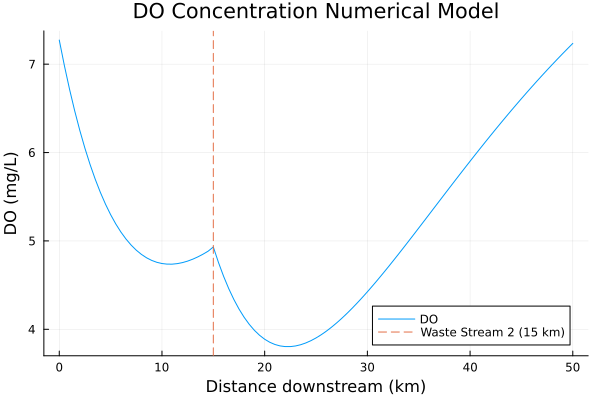

In [4]:

# first, given parameters
v = 6.0 # km/d               
k2 = 0.55 # 1/d             
k1_cbod = 0.35 #1/d        
k1_nbod = 0.25 #1/d      
DO_sat = 10.0 #mg/L          

# River Inflow
Qr, DOr, CBODr, NBODr = 100_000.0, 7.5, 5, 5

# Waste Stream 1
Qw1, DOw1, CBODw1, NBODw1 = 10_000.0, 5, 50, 35

# Waste Stream 2
Qw2, DOw2, CBODw2, NBODw2 = 15_000.0, 5, 45, 35

xw1 = 0.0 # starting point/origin      
xw2 = 15.0

# Assuming conservative, instantaneous mixing 
function Cmix(Q1, C1, Q2, C2)
    Q = Q1 + Q2
    if Q != 0.0
        return (Q1*C1 + Q2*C2) / Q
    end
    return 0.0
end

# concentrations @ x=0 (waste stream 1)
Q1 = Qr + Qw1
DO_w1 = Cmix(Qr, DOr, Qw1, DOw1)
CBOD_w1 = Cmix(Qr, CBODr, Qw1, CBODw1)
NBOD_w1 = Cmix(Qr, NBODr, Qw1, NBODw1)

# DO deficit immediately after waste stream 1
D0_1 = DO_sat - DO_w1

# Two equations: 
# 1) Exact exponential decay for L: L(t+dt) = L(t)*exp(-k1dt)
# 2) Forward Euler for DO deficit: dD/dt = -k2*D + k1_cbod*L1 + k1_nbodL2

function DO_numeric(xmax, res=0.5)
    x_array = 0:res:xmax # step size res, 0-xmax
    n = length(x_array)
    DO_num, L1_num, L2_num = zeros(n), zeros(n), zeros(n)

    # @ x=w1 (after first mixing)
    DO_num[1] = DO_w1
    L1_num[1] = CBOD_w1
    L2_num[1] = NBOD_w1
    Q = Qr + Qw1
    
    # @ x=w2)
    # Exact exponential decay for L: L(t+dt) = L(t)*exp(-k1dt)
    for i in 2:n
        xprev = x_array[i-1]
        xcurr = x_array[i]
        dt = (xcurr - xprev)/v
        L1 = L1_num[i-1] * exp(-k1_cbod*dt)
        L2 = L2_num[i-1] * exp(-k1_nbod*dt)

        # Forward Euler for DO deficit: dD/dt = -k2*D + k1_cbod*L1 + k1_nbodL2
        D_prev = DO_sat - DO_num[i-1]
        dD_dt = -k2 * D_prev + k1_cbod * L1 + k1_nbod * L2
        DO_new = DO_sat - (D_prev + dD_dt * dt)

        # instant mixing @ location where xw1 and xw2 combine (using Q and Q_w2)
        if xprev < xw2  && xcurr >= xw2
            Q_before = Qr + Qw1
            DO_mixed = Cmix(Q_before, DO_new, Qw2, DOw2)
            # For the L's, L1 and L2 above represent the decayed values at the mixing point
            CBOD_mixed = Cmix(Q_before, L1, Qw2, CBODw2)
            NBOD_mixed = Cmix(Q_before, L2, Qw2, NBODw2)
            DO_new = DO_mixed
            L1 = CBOD_mixed
            L2 = NBOD_mixed
            Q = Q_before + Qw2
        end
        DO_num[i] = DO_new
        L1_num[i] = L1
        L2_num[i] = L2
    end

    return x_array, DO_num, L1_num, L2_num
end

# compute the minimum dissolved oxygen concentration up to 50 km downstream (res = 0.5)
x_vals, DO_vals, L1_vals, L2_vals = DO_numeric(50.0, 0.5)

# find minimum DO 
min_DO = minimum(DO_vals)
# find how far downriver this minimum occurs
x_min = x_vals[argmin(DO_vals)]

println("Minimum DO =", min_DO, " mg/L at x =", x_min, " km downstream")

# PLOT
p = plot(
    x_vals, DO_vals,
    label = "DO",
    xlabel = "Distance downstream (km)",
    ylabel = "DO (mg/L)",
    title = "DO Concentration Numerical Model",
)

# 15km identification (xw2)
vline!(p, [xw2], label = "Waste Stream 2 (15 km)", linestyle = :dash)
display(p)

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

To keep the DO concentration above 4 mg/L, I would opt to treate waste stream 2 more than waste stream 1. It is true that treating the discharge from waste stream 1 could prevent the oxygen sag earlier and thus reduce downstream impacts from waste stream 2. However, it can be seen from the graphs that from both methods, the first DO sag (from waste stream 1) doesn't reach 4 mg/L at all, while the global minimum DO occurs after waste stream 2. In addition, calculating and comparing the mass BOD loadings for both waste streams:

$$
Qw1*(CBOD_w1+NBOD_w1) = 10,000 * (50+35) = 850,000 mg.
$$

$$
Qw2*(CBOD_w2+NBOD_ww) = 15,000 * (45+35) = 1,200,000 mg
$$

It can be seen that that waste stream 2 contributes more BOD mass. Other information that could be useful in making a more informed conclusion could be the costs for each plant (if there are any differences), potential DO variability due to seasonal temperature and flow differences, as well as circumstantial environments around both waste streams (eg. which aquatic habitat is more sensitive?). 

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

## References

List any external references consulted, including classmates.